In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

In [28]:
df = pd.read_csv('Fish.csv')

In [29]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


## representation

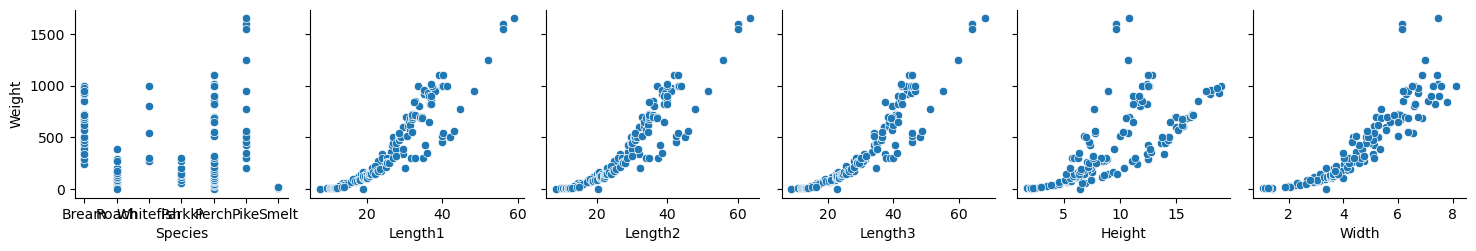

In [31]:
sns.pairplot(df, y_vars="Weight", x_vars=df.drop(columns="Weight").columns)
plt.show()

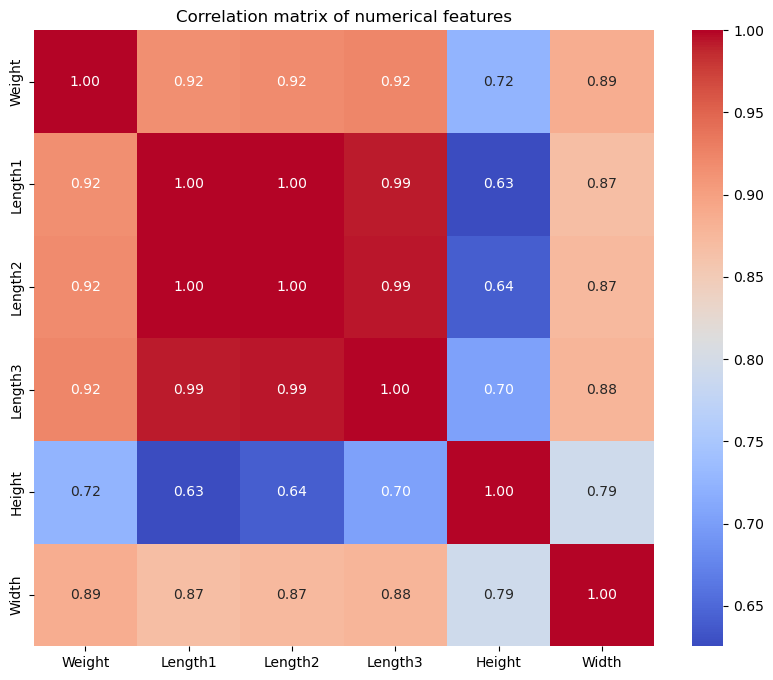

In [32]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=["int64", "float64"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation matrix of numerical features")
plt.show()


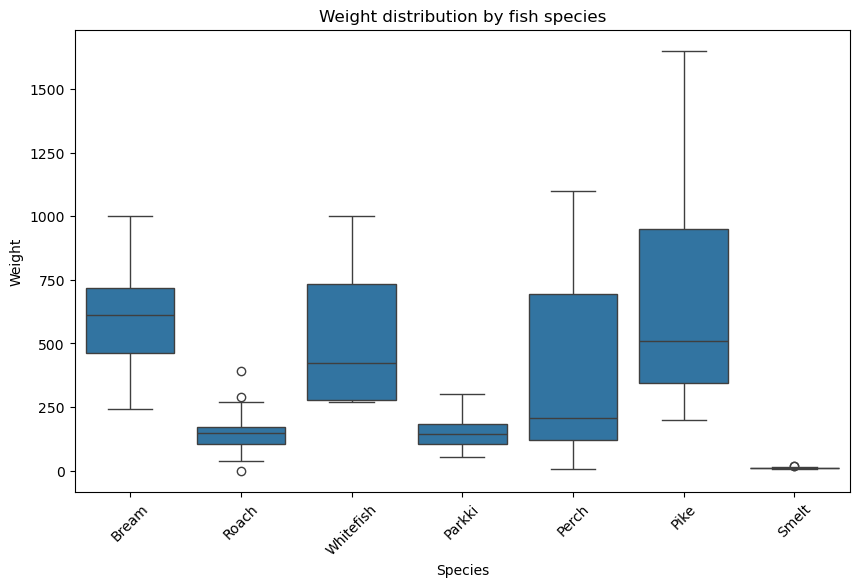

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Species", y="Weight")

plt.title("Weight distribution by fish species")
plt.xticks(rotation=45)
plt.show()


In addition to the pairplot, a correlation heatmap was used to identify the most relevant numerical features for predicting fish weight. A boxplot by species highlights the importance of categorical information in the prediction task.

## ML

In [34]:
X = df.drop(columns="Weight")
y = df["Weight"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
num_features

Index(['Length1', 'Length2', 'Length3', 'Height', 'Width'], dtype='object')

In [37]:
cat_features = X.select_dtypes(include=["object"]).columns
cat_features

Index(['Species'], dtype='object')

### linear regression

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features)
    ]
)

In [39]:
baseline_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

In [40]:
baseline_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Length1', 'Length2', 'Length3', 'Height', 'Width'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['Species'], dtype='object'))])),
                ('model', LinearRegression())])

In [41]:
y_pred_baseline = baseline_pipeline.predict(X_test)

In [42]:
rmse_baseline = mean_squared_error(y_test, y_pred_baseline, squared=False)
r2_baseline = r2_score(y_test, y_pred_baseline)
rmse_baseline, r2_baseline

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(83.7101140236594, 0.9507352480054504)

### ridge

In [43]:
ridge_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", Ridge(alpha=1.0))
])

In [44]:
ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)


In [45]:
rmse_ridge = mean_squared_error(y_test, y_pred_ridge, squared=False)
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge, r2_ridge

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(88.23700054959772, 0.9452628845434945)

In [46]:
results = pd.DataFrame({
    "Model": ["Baseline (Linear)", "Ridge"],
    "RMSE": [rmse_baseline, rmse_ridge],
    "R2": [r2_baseline, r2_ridge]
})
results

,Model,RMSE,R2
0,Baseline (Linear),83.710114,0.950735
1,Ridge,88.237001,0.945263
